# Linear Discriminant Analysis
Linear discriminant analysis was developed to model gaussian physical measurements when conditioned on a class (particularly Iris flowers) as a generative classification technique.

As discussed in the [classification readme](../../../README.md), generative methods try to estimate the bayes optimal classifier by factoring the posterior into the likelihood and prior.

$$
P(Y = y_c | X = x) = \frac{P(X = x | Y = y_c) \cdot P(Y = y_c)}{P(X=x)}
$$

Then we estimate likelihood and prior and multiply them to get an equivalent (since the marginal distribution of the data is the same for each class) quantity to the posterior, then after we have our posterior equivalents, picking the maximum of this quantity:

$$
\hat{f}(x) = \text{argmax}_{\text{y}_c} {\frac{P(X = x | Y = y_c) \cdot P(Y = y_c)}{P(X=x)}} \\
= \text{argmax}_{\text{y}_c} {P(X = x | Y = y_c) \cdot P(Y = y_c)}
$$

In the original context of LDA, the measurements of flowers were observed to be normally distributed based on their class so modeling the likelihood was straightforward.

It's straightforward to estimate the prior aspect, just getting the proportion of the class in the training data $(P(Y=y_c))$.

For the conditional likelihood by default (and because the ubiquity of guassian random variables) we assume the data is a multivariate gaussian in discrimnant analysis:

$$
X | {Y = y_c} \sim N(\mu_{y_c}, \Sigma_{y_c})
$$

With the following density function:

$$
pdf(X=x | Y = y_c) = \frac{1}{(2 \cdot \pi)^{\frac{2}{p}} \cdot |\Sigma_{y_c}|^{1/2}}e^{-\frac{1}{2}(x - \mu_c)^T\Sigma^{-1}(x - \mu_c)}
$$

In the same wa we ignored the marginal distribution of X for the posterior to get an equivalent quantity, we can do the same with the terms multiplied outside of expontential to get a equivalent expression to minimize (since they're constant across classes), also if we use the rank preserving transformation of log on the exponential we get the following equivalent expression to maximize across classes:

$$
log(pdf(X=x | Y = y_c)) \sim -\frac{1}{2}(x - \mu_c)^T\Sigma^{-1}_{y_c}(x - \mu_c) - log(|\Sigma_{y_c}|^{1/2})
$$

The linear part of linear discriminant analysis by assuming $\Sigma_{y_c} = \Sigma$:

$$
log(pdf(X=x | Y = y_c)) \sim -\frac{1}{2}(x - \mu_c)^T\Sigma^{-1}_{y_c}(x - \mu_c)
$$

And the decision boundary (equal probability of to most likely classes) becomes linear:

$$
log(pdf(X=x | Y = y_1)) + log(P(Y = y_1)) = log(pdf(X=x | Y = y_2)) + log(P(Y = y_2)) \\
-\frac{1}{2}(x - \mu_1)^T\Sigma^{-1}(x - \mu_1) + log(P(Y = y_1))= -\frac{1}{2}(x - \mu_2)^T\Sigma^{-1}(x - \mu_2) + log(P(Y = y_2))\\
-\frac{1}{2}(x^T\Sigma^{-1}x - 2 x^T \Sigma^{-1}\mu_1 + \mu_1^T\Sigma^{-1}\mu_1 - 2 log(P(Y = y_1))) = -\frac{1}{2}(x^T\Sigma^{-1}x - 2 x^T \Sigma^{-1}\mu_2 + \mu_2^T\Sigma^{-1}\mu_2 - 2log(P(Y = y_2))) \\ 
\mu_1^T\Sigma^{-1}\mu_1 - 2 x^T \Sigma^{-1}\mu_1 - 2log(P(Y = y_1))= \mu_2^T\Sigma^{-1}\mu_2 - 2 x^T \Sigma^{-1}\mu_2 -  2log(P(Y = y_2))
$$

If we don't assume a common covariance the problem becomes Quadratic Discriminant Analysis (QDA) and the boundary is quadratic, a subject of study outside of this notebook but we do look at it in the non-linear classification section of this repository.

Let's start with a generated example that matches the assumptions here.

### Generated Problem

In [1]:
import numpy as np
random_matrix = np.random.uniform(-1, 1, (3,3))

common_covariance_matrix = random_matrix @ random_matrix.T
labeled_0_data = np.random.multivariate_normal([-1, -1.5, 2], common_covariance_matrix, (1000))
labeled_1_data = np.random.multivariate_normal([.5, -1.5, 1], common_covariance_matrix, (1000))

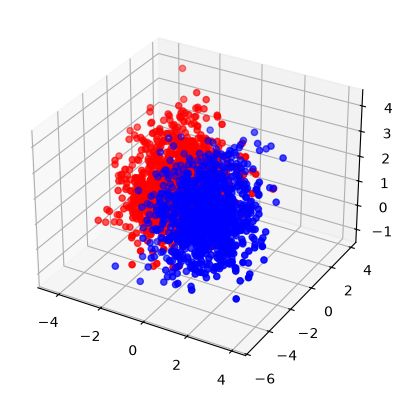

In [2]:
import matplotlib.pyplot as plt

ax = plt.figure().add_subplot(projection="3d")
ax.scatter3D(xs=labeled_0_data[:, 0], ys=labeled_0_data[:, 1], zs=labeled_0_data[:, 2], c="red")
ax.scatter3D(xs=labeled_1_data[:, 0], ys=labeled_1_data[:, 1], zs=labeled_1_data[:, 2], c="blue")
plt.show()

So above is the ground truth, now let's mix up the points.

In [3]:
dataset = np.concat([np.concat([labeled_0_data, np.zeros(shape=(labeled_0_data.shape[0], 1))], axis=1), np.concat([labeled_1_data, np.ones(shape=(labeled_1_data.shape[0], 1))], axis=1)], axis=0)
np.random.shuffle(dataset)
training_dataset = dataset[:1600, :]
test_dataset = dataset[:1600, :]

(training_dataset[:, -1] == 1).mean(), (test_dataset[:, -1] == 1).mean()

(np.float64(0.494375), np.float64(0.494375))

In [4]:
cov_label_1 = np.cov(training_dataset[training_dataset[:, -1] == 1][:, :-1], bias=False, rowvar=False)
cov_label_0 = np.cov(training_dataset[training_dataset[:, -1] == 0][:, :-1], bias=False, rowvar=False)
cov = ((training_dataset[training_dataset[:, -1] == 1].shape[0] - 1) * cov_label_1 + (training_dataset[training_dataset[:, -1] == 0].shape[0] - 1) * cov_label_0) / (training_dataset.shape[0] - 2)

In [5]:
cov, common_covariance_matrix

(array([[ 1.51841937, -0.55751647,  0.0628127 ],
        [-0.55751647,  1.55946014,  0.61031369],
        [ 0.0628127 ,  0.61031369,  0.48937106]]),
 array([[ 1.56477438, -0.47891258,  0.10173017],
        [-0.47891258,  1.56403696,  0.64476596],
        [ 0.10173017,  0.64476596,  0.5154586 ]]))

Not bad on estimating our covariance matrix from our data, now for our means.

In [6]:
mean_label_1 = training_dataset[training_dataset[:, -1] == 1][:, :-1].mean(axis=0)
mean_label_0 = training_dataset[training_dataset[:, -1] == 0][:, :-1].mean(axis=0)


In [7]:
mean_label_0, [-1, -1.5, 2]

(array([-0.89126001, -1.54501325,  1.98471398]), [-1, -1.5, 2])

In [8]:
mean_label_1, [.5, -1.5, 1]

(array([ 0.44587362, -1.49417959,  0.99156438]), [0.5, -1.5, 1])

In [9]:
marginal_1 = (training_dataset[:, -1] == 1).mean()
marginal_0 = 1 - marginal_1
marginal_1, marginal_0

(np.float64(0.494375), np.float64(0.505625))

Means are estimated nicely too.
With that training is done, now lets write our inference function and test it against our test dataset.

In [10]:
def predict_class(points, label_1_mean, label_0_mean, cov, marginal_1, marginal_0):
    inv_cov = np.linalg.inv(cov)
    offset_0 = label_0_mean.T @ inv_cov @ label_0_mean
    offset_1 = label_1_mean.T @ inv_cov @ label_1_mean

    linear_0 = 2 * points @ inv_cov @ label_0_mean
    linear_1= 2 * points @ inv_cov @ label_1_mean

    score_0 = offset_0 - linear_0 - 2*np.log(marginal_0)
    score_1 = offset_1 - linear_1 - 2*np.log(marginal_1)
    return (score_0 > score_1).astype(float)

result = predict_class(test_dataset[:, :-1], mean_label_1, mean_label_0, cov, marginal_1, marginal_0)

(result == test_dataset[:, -1]).mean()

np.float64(0.9475)

In [11]:
result = predict_class(test_dataset[:, :-1], np.array([.5, -1.5, 1]), np.array([-1, -1.5, 2]), common_covariance_matrix, 0.5, 0.5)

(result == test_dataset[:, -1]).mean()

np.float64(0.94625)

Our estimated model's error is within 0.2% of the true Bayes error rate, which is the best possible performance since we know the exact data generating process.

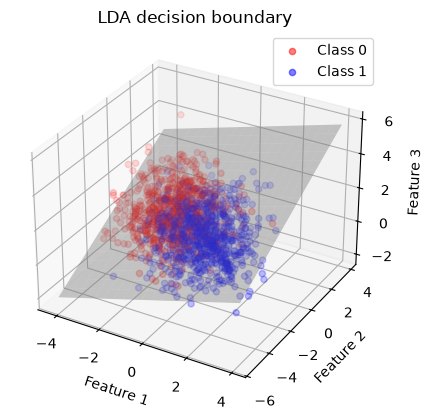

In [12]:
import matplotlib.pyplot as plt

inv_cov = np.linalg.inv(cov)

W = 2*(inv_cov @ mean_label_1 - inv_cov @ mean_label_0)

D = mean_label_1.T @ inv_cov @ mean_label_1 - mean_label_0.T @ inv_cov @ mean_label_0 - 2*np.log(marginal_1) + 2 * np.log(marginal_0)

x_min, x_max = test_dataset[:, 0].min(), test_dataset[:, 0].max()
y_min, y_max = test_dataset[:, 1].min(), test_dataset[:, 1].max()

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))

zz = (D - W[0]*xx - W[1]*yy) / W[2]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

test_0 = test_dataset[test_dataset[:, -1] == 0]
test_1 = test_dataset[test_dataset[:, -1] == 1]

ax.scatter3D(test_0[:, 0], test_0[:, 1], test_0[:, 2], c="red", alpha=0.5, label="Class 0")
ax.scatter3D(test_1[:, 0], test_1[:, 1], test_1[:, 2], c="blue", alpha=0.5, label="Class 1")

ax.plot_surface(xx, yy, zz, color="gray", alpha=0.4, edgecolor="none")

ax.set_title("LDA decision boundary")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.legend()
plt.show()

### Handling discrete features

Because LDA assumes features follow a Gaussian distribution, it inherently precludes the use of discrete features. If you have discrete features, there are ways to combine multivariate Gaussians for continuous features and probability mass functions for discrete features via how we model the likelihood. 

For example, the joint likelihood $P(X_{continuous}, X_{discrete} = x)$ can be decomposed into conditional probabilities: $P(X_{continuous} \mid X_{discrete} = x) \cdot P(X_{discrete} = x)$. However, this approach can fail if you lack the sample density required to estimate the conditional distribution for rare classes. This approach is a foundational part of Bayesian networks.

We could also assume the features are independent, so that their joint likelihood is simply their product (more of a Naive Bayes approach), but that introduces a heavy bias.

For this notebook, we will focus on classic LDA and leave Bayesian networks for another notebook.

### Handling multi-class classification

To use LDA for multi-class (or multinomial) classification, we simply perform the same exact steps for every single class. For a given data point, we calculate the score proportional to the posterior probability for each class, and assign the point to whichever class yields the highest score.

The decision boundaries are completely piecewise linear. They are drawn exactly where the scores of the two most likely classes in a particular region of space are perfectly equal.

For below demonstration we'll generate a dataset and use a production quality library to do our LDA.

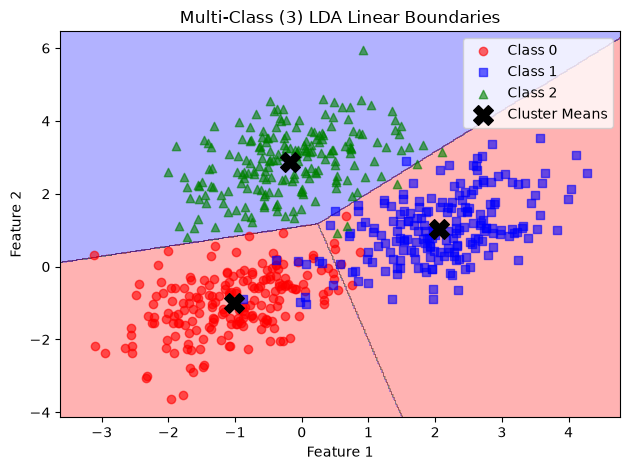

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

np.random.seed(42)

common_cov = np.array([[0.8, 0.4], [0.4, 0.8]])

mean_0 = np.array([-1, -1])
mean_1 = np.array([2, 1])
mean_2 = np.array([0, 3])

X0 = np.random.multivariate_normal(mean_0, common_cov, 200)
X1 = np.random.multivariate_normal(mean_1, common_cov, 200)
X2 = np.random.multivariate_normal(mean_2, common_cov, 200)

X = np.concatenate([X0, X1, X2])
y = np.array([0] * 200 + [1] * 200 + [2] * 200)


lda = LinearDiscriminantAnalysis(solver='svd', store_covariance=True)
lda.fit(X, y)


x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.02

xx, yy = np.meshgrid(np.linspace(x_min, x_max, int((x_max - x_min) / h)), 
                     np.linspace(y_min, y_max, int((y_max - y_min) / h)))

zz_shaped = lda.predict(np.c_[xx.ravel(), yy.ravel()])
zz_reshaped = zz_shaped.reshape(xx.shape)

fig, ax = plt.subplots()

ax.contourf(xx, yy, zz_reshaped, colors=['red', 'blue', 'green'], alpha=0.3, zorder=-1)

ax.scatter(X[y == 0, 0], X[y == 0, 1], c="red", marker='o', alpha=0.6, label="Class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", marker='s', alpha=0.6, label="Class 1")
ax.scatter(X[y == 2, 0], X[y == 2, 1], c="green", marker='^', alpha=0.6, label="Class 2")

means = lda.means_
ax.scatter(means[:, 0], means[:, 1], c="black", marker='X', s=200, zorder=10, label="Cluster Means")

ax.set_title("Multi-Class (3) LDA Linear Boundaries")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()

## Two goals
As with our other algorithms, we can either go after inference performance or interpretability.

### Interpretability
LDA assumes features are multivariate gaussian, centered at their class specific calculated means, and with a shared class covariance matrix that we estimated from our data. If these assumptions are valid we can look at weights for feature importance and partial effects, understand prototypical profiles of our classes and produce confidence scores.

We can test those assumptions:

1. Mardia's test tests if the data actually follows a multivariate guassian.
2. Box's M test tests if the covariance matrix of Class 0 and Class 1 are actually equal.

We need these for interpertability because the entire model hinges on how we calculate the likelihood of seeing a data point given a class: $P(X∣Y)$ to get our posterior confidence scores, and the weights that are derived from the common covariance are directly related to how we view $\Sigma$ which can be used for feature importance.

#### Mardia's Test

Mardia's test is a hypothesis test whose null hypothesis is that the data comes from a multivariate normal distribution. It is the multivariate extension of the simpler univariate Gaussian tests, which look at two key properties:
*   **Skewness (lean):** The 3rd moment (the average cubed deviation from the mean). For a perfect 1D Gaussian, this is 0, as the negative and positive deviations perfectly balance out.
*   **Kurtosis (tail size):** The 4th moment (the average deviation from the mean to the fourth power). For a perfect 1D Gaussian, this is exactly 3.

The test computes two quantities—Mardia's multivariate skewness and Mardia's multivariate kurtosis—which are then evaluated against a Chi-Square distribution to generate a p-value. 

A $p > 0.05$ means failing to reject the null, meaning we can assume the data is from a multivariate Gaussian. If the p-value is smaller, then the data is skewed or has extreme outlier tails, violating the LDA assumption. This would ultimately lead to untrustworthy confidence scores.

In [14]:
import pandas as pd
import pingouin as pg

X_class_0 = test_dataset[test_dataset[:, -1] == 0][:, :-1]
X_class_1 = test_dataset[test_dataset[:, -1] == 1][:, :-1]

df_class_0 = pd.DataFrame(X_class_0, columns=['Feature_1', 'Feature_2', 'Feature_3'])
df_class_1 = pd.DataFrame(X_class_1, columns=['Feature_1', 'Feature_2', 'Feature_3'])


hz_0, p_val_0, is_normal_0 = pg.multivariate_normality(df_class_0, alpha=0.05)
hz_1, p_val_1, is_normal_1 = pg.multivariate_normality(df_class_1, alpha=0.05)

print("Mardia's test on our example data:")
print(f"Class 0 Multivariate Gaussian? : {is_normal_0} (p-value = {p_val_0:.4f})")
print(f"Class 1 Multivariate Gaussian? : {is_normal_1} (p-value = {p_val_1:.4f})")

bad_data = np.random.exponential(scale=1.0, size=(500, 3))
df_bad = pd.DataFrame(bad_data, columns=['F1', 'F2', 'F3'])

is_normal_bad, p_value_bad, is_normal_bad = pg.multivariate_normality(df_bad, alpha=0.05)

print("Mardia's test on exponential data:")
print(f"Exponential Data Gaussian? : {is_normal_bad} (p-value = {p_value_bad:.4f})")

Mardia's test on our example data:
Class 0 Multivariate Gaussian? : True (p-value = 0.6754)
Class 1 Multivariate Gaussian? : True (p-value = 0.0773)
Mardia's test on exponential data:
Exponential Data Gaussian? : False (p-value = 0.0000)


#### Box's M Test

Box's M test is a hypothesis test whose null hypothesis is that each class has the same covariance matrix. It uses the determinant of the covariance matrix, which shows how the space is warped in the distribution compared to a standard normal. 

Because this test is highly sensitive to the underlying distribution, it is critical to run it only *after* confirming multivariate normality (e.g., via Mardia's test); otherwise, the results can be highly unreliable.

A $p > 0.05$ means we fail to reject the null hypothesis, meaning we can safely assume the classes share a pooled covariance matrix. If the p-value is smaller, the pooled covariance is not a valid estimate. In that case, we should pivot to Quadratic Discriminant Analysis (QDA)—which we cover in another notebook—since it explicitly models distinct covariances for every class.

In [15]:
#### Box M's Test
import pandas as pd
import pingouin as pg


df_box = pd.DataFrame(
    test_dataset, 
    columns=['Feature_1', 'Feature_2', 'Feature_3', 'Label']
)


box_results = pg.box_m(df_box, dvs=['Feature_1', 'Feature_2', 'Feature_3'], group='Label')

print("--- Assumption Diagnostic: Box's M Test ---")
display(box_results)

--- Assumption Diagnostic: Box's M Test ---


,Chi2,df,pval,equal_cov
box,4.701197,6.0,0.582667,True


#### Interpreting confidence scores and feature importance 

After confirming our assumptions, we can get exact probabilistic confidence scores for each class by applying the softmax function to our log-posterior scores (logits). The softmax formula for class $i$ is: 
$$P(Y=i \mid X) = \frac{e^{logit_i}}{\sum_c e^{logit_c}}$$

If you work out the math, the proportionality constant (which is the marginal probability $P(X)$) perfectly cancels out in the numerator and denominator, leaving us with the true posterior probability.


In [16]:
def predict_proba_binary(points, label_1_mean, label_0_mean, cov, marginal_1, marginal_0):
    inv_cov = np.linalg.inv(cov)
    offset_0 = label_0_mean.T @ inv_cov @ label_0_mean
    offset_1 = label_1_mean.T @ inv_cov @ label_1_mean

    linear_0 = 2 * points @ inv_cov @ label_0_mean
    linear_1= 2 * points @ inv_cov @ label_1_mean

    score_0 = offset_0 - linear_0 - 2*np.log(marginal_0)
    score_1 = offset_1 - linear_1 - 2*np.log(marginal_1)
    return (1 / (1 + np.exp(-(score_0 - score_1) / 2))).astype(float) # sigmoid equivalency trick here

predict_proba_binary(np.array([.5, -1.5, 1]), mean_label_1, mean_label_0, cov, marginal_1, marginal_0)

np.float64(0.9943726908236282)

Furthermore, we can interpret the feature importance simply by looking at the magnitude and sign of the learned linear weights ($W$). A larger absolute weight means that specific feature has a stronger influence on pushing the model toward a certain class prediction.

If we subtract score 0 from score 1 and isolate what multiplies our features, we get:

$$ \Sigma^{-1} \cdot (\mu_1 - \mu_0) $$

So, the weight vector is exactly this whitened distance from the centroids (aftering whitening the x point in front of it), and its value dictates how much each feature pushes the score into Class 1.

In [19]:
inv_cov = np.linalg.inv(cov)
coefficients = inv_cov @ (mean_label_1 - mean_label_0)
coefficients

array([ 2.48194125,  3.59204197, -6.82778307])

By exponentiating a specific feature's weight, we get its odds ratio. This tells us the exact multiplicative effect on the odds ($\frac{p}{1-p}$) of belonging to Class 1 for every 1-unit increase in that feature, assuming all other features are held constant.

In [21]:
np.exp(coefficients)

array([1.19644679e+01, 3.63081405e+01, 1.08325696e-03])

### Inference Performance
For inference performance, we can evaluate the standard classification metrics and estimate generalization performance as discussed in our repository's [README.md](../../../../README.md) and the classification [README.md](../../../README.md). 

Unlike more complex models, standard LDA is parameter-free. However, in real-world, high-dimensional applications, we run into an issue where the covariance matrix estimate may be ill-conditioned due to having too few samples relative to the dimensionality. Inverting this matrix mathematically amplifies the effect of those undersampled estimates. This makes the model extremely sensitive to the specific training samples used—which is the exact definition of high model variance.

The standard way to control this overfitting is to use covariance shrinkage, where a hyperparameter ($\alpha$) controls how much we mix our noisy sample covariance with a perfectly stable identity matrix:

$$
\Sigma_{\text{shrunk}} = (1 - \alpha)\Sigma + \alpha I 
$$

*   If $\alpha$ is 1, we completely discard our learned covariance and use the identity matrix, essentially assuming all features are independent (turning this into Gaussian Naive Bayes). This yields heavy bias, but extremely low variance.
*   If $\alpha$ is 0, we use standard LDA, exposing us to the high-variance vulnerabilities of our raw data.

Ultimately, we can use cross-validation to find the optimal covariance shrinkage ($\alpha$), perfectly balancing the bias-variance tradeoff to maximize our model's generalization performance.

In [24]:
def predict_class_cov_shrinkage(points, label_1_mean, label_0_mean, cov, marginal_1, marginal_0, shrinkage):
    cov = cov*(1 - shrinkage) + shrinkage * np.eye(cov.shape[0])
    inv_cov = np.linalg.inv(cov) 
    offset_0 = label_0_mean.T @ inv_cov @ label_0_mean
    offset_1 = label_1_mean.T @ inv_cov @ label_1_mean

    linear_0 = 2 * points @ inv_cov @ label_0_mean
    linear_1= 2 * points @ inv_cov @ label_1_mean

    score_0 = offset_0 - linear_0 - 2*np.log(marginal_0)
    score_1 = offset_1 - linear_1 - 2*np.log(marginal_1)
    return (score_0 > score_1).astype(float)

for shrinkage in np.linspace(0, 1, 10):
    result = predict_class_cov_shrinkage(test_dataset[:, :-1], mean_label_1, mean_label_0, cov, marginal_1, marginal_0, shrinkage)
    print(f"Shrinkage: {shrinkage} | test performance:{(result == test_dataset[:, -1]).mean()}")

Shrinkage: 0.0 | test performance:0.9475
Shrinkage: 0.1111111111111111 | test performance:0.944375
Shrinkage: 0.2222222222222222 | test performance:0.9375
Shrinkage: 0.3333333333333333 | test performance:0.92125
Shrinkage: 0.4444444444444444 | test performance:0.90125
Shrinkage: 0.5555555555555556 | test performance:0.885625
Shrinkage: 0.6666666666666666 | test performance:0.85625
Shrinkage: 0.7777777777777777 | test performance:0.830625
Shrinkage: 0.8888888888888888 | test performance:0.8075
Shrinkage: 1.0 | test performance:0.779375


## Industry Standard libraries

### Interpretability & Statistical Rigor (pingouin)
Because LDA is a generative model, evaluating feature importance requires testing the mean differences of the classes rather than estimating weights directly. The pingouin Python library is the modern industry standard for this, as it provides clean, pandas-native statistical testing:

### Standard Inference Performance (scikit-learn)
When the goal is raw predictive power and hyperparameter tuning on datasets that fit into RAM, we use sklearn.discriminant_analysis.LinearDiscriminantAnalysis.

The Default Solver (svd): Singular Value Decomposition is incredibly fast and does not require explicitly computing the full covariance matrix, making it highly efficient for datasets with many features.

Regularization Solvers (lsqr or eigen): If your dataset is undersampled and you need to apply the covariance shrinkage (α) hyperparameter we discussed earlier, you must switch to one of these solvers to natively handle the identity matrix blending.

### Scaling beyond
For beyond a few tens of thousands of features, LDA becomes intractable due to inverting the covariance matrix which is $O(p^3)$. In practice for large jobs, most switch to logistic regression and gradient descent.

## Real Dataset - Iris
The Iris dataset was what spurred the invention of LDA. Lets look at interpertability and then inference performance.

### EDA
The dataset is multi class classification of flowers using their physical petal dimensions.

In [26]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [28]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [29]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

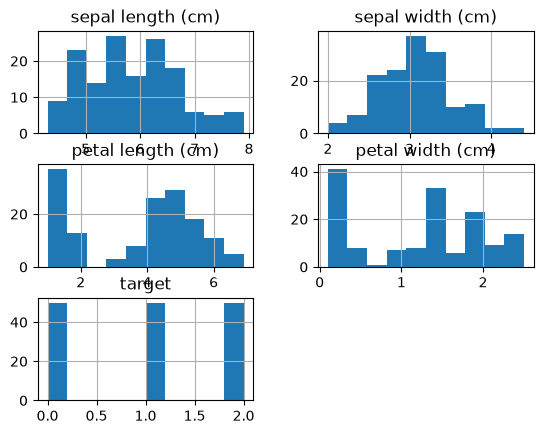

In [32]:
df.hist()
plt.show()

In [33]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Balanced 3 classes distributions look logical.

### Interpertability
From EDA, looks like we have a mix of class specific gaussians, but lets rigorously test this:

In [51]:
import pingouin as pg
columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)']
for target in df["target"].drop_duplicates().to_list():
    df_target = df[df["target"] == target][columns]
    print(f"Class: {iris.target_names[target]}, Not multi variate guassian p-value: {pg.multivariate_normality(df_target).pval}")

Class: setosa, Not multi variate guassian p-value: 0.04995355617922568
Class: versicolor, Not multi variate guassian p-value: 0.22619914870368246
Class: virginica, Not multi variate guassian p-value: 0.4970236922155737


Seems mostly multivariate normal except setosa, but its right on the border, lets accept it for now.

What about pooled covariance?

In [52]:
results = pg.box_m(df, dvs=columns, group="target")

results

,Chi2,df,pval,equal_cov
box,140.94305,20.0,3.352034e-20,False


So probably not equal covariance! let's visualize it.

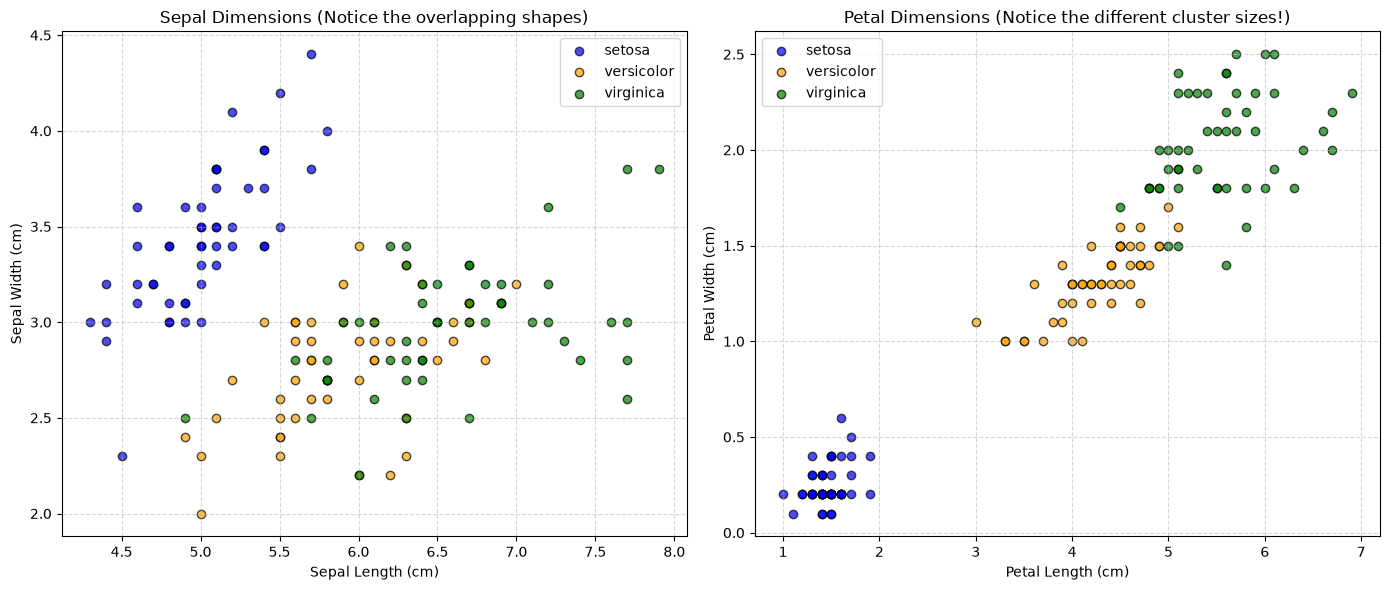

In [53]:
import matplotlib.pyplot as plt

# Set up a 1x2 grid of plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['blue', 'orange', 'green']

# Loop through each species to plot them in different colors
for i, target_name in enumerate(iris.target_names):
    # Filter the dataframe for the current species
    subset = df[df['target'] == i]
    
    # Left Plot: Sepal Dimensions
    ax1.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], 
                label=target_name, color=colors[i], alpha=0.7, edgecolors='k')
    
    # Right Plot: Petal Dimensions
    ax2.scatter(subset['petal length (cm)'], subset['petal width (cm)'], 
                label=target_name, color=colors[i], alpha=0.7, edgecolors='k')

# Formatting Left Plot
ax1.set_title('Sepal Dimensions (Notice the overlapping shapes)')
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Sepal Width (cm)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Formatting Right Plot
ax2.set_title('Petal Dimensions (Notice the different cluster sizes!)')
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Yeah so their spread is clearly different. At this point I would switch over to QDA for interpretability. Please see the QDA notebook in our repository for that analysis.

#### Inference example
Let's now use LDA and optimize for generalization performance. 

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
model = LinearDiscriminantAnalysis(solver="lsqr")
dataset = np.concat([iris.data, iris.target.reshape(-1, 1)], axis=1)
np.random.shuffle(dataset)
training = dataset[:120]
test = dataset[120:]

In [2]:
grid_search_cv = GridSearchCV(estimator=model, scoring="accuracy", cv=10, param_grid={
    'shrinkage': np.linspace(0, 1, 10),
})

grid_search_cv.fit(training[:, :-1], training[:, -1])
grid_search_cv.best_score_

np.float64(0.975)

In [3]:
grid_search_cv.score(test[:, :-1], test[:, -1]), grid_search_cv.best_params_

(1.0, {'shrinkage': np.float64(0.0)})

In [4]:
grid_search_cv.cv_results_["mean_test_score"]

array([0.975     , 0.975     , 0.96666667, 0.96666667, 0.95833333,
       0.96666667, 0.95833333, 0.95833333, 0.95      , 0.925     ])

So we see no shrinkage works best and gives us 96%. This tracks since shrinkage combats variance only when theres low sample density with regard to features ($n < p$).

Now lets set up an API for inference!

In [7]:
!mkdir -p .data

In [8]:
import joblib

joblib.dump(grid_search_cv.best_estimator_, ".data/lda_model.pkl")


['.data/lda_model.pkl']

In [9]:
%%writefile .data/server.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

# 1. Initialize app and load model at startup
app = FastAPI()
model = joblib.load("lda_model.pkl")

# 2. Define the expected JSON payload
class FlowerData(BaseModel):
    features: list[float]

# 3. Define the prediction endpoint
@app.post("/predict")
def predict(data: FlowerData):
    # Reshape the 1D list into a 2D numpy array (1 row, 4 columns)
    X = np.array(data.features).reshape(1, -1)
    
    # Run inference
    prediction = model.predict(X)
    
    # Return standard JSON response
    return {"predicted_class": int(prediction[0])}

Writing .data/server.py


In [18]:
import subprocess
import time

# Boot up the uvicorn server in a background process
server_process = subprocess.Popen(
    ["uvicorn", "server:app", "--host", "127.0.0.1", "--port", "8000"],
    cwd=".data"
)

# Give the server 3 seconds to fully initialize
time.sleep(3)
print("Server is up and running on port 8000!")

INFO:     Started server process [40827]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


Server is up and running on port 8000!


In [19]:
test[0, :-1].tolist(), test[0, -1]

([5.0, 3.4, 1.5, 0.2], np.float64(0.0))

In [20]:
import requests

# Send the POST request
url = "http://127.0.0.1:8000/predict"
payload = {"features": test[0, :-1].tolist()}
response = requests.post(url, json=payload)

print(f"Status Code: {response.status_code}")
print(f"API Response: {response.json()}")

# Kill the background web server when done testing
server_process.terminate()
print("Server shut down successfully.")

INFO:     127.0.0.1:65425 - "POST /predict HTTP/1.1" 200 OK
Status Code: 200
API Response: {'predicted_class': 0}
Server shut down successfully.


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [40827]
